In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns


# STEP 1: LOAD DATA FROM CSV INTO PANDAS
df = pd.read_csv('healthcare_dataset.csv')
print(" RAW DATA ")
print(f"Initial Shape: {df.shape}")
df.head()
print(df.columns)

 RAW DATA 
Initial Shape: (55500, 15)
Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='str')


In [65]:
# Convert CSV into Excel
df.to_excel('healthcare_dataset.xlsx',index=False,sheet_name='Patient_Data')

print("Successful conversion!")
print(df.shape)
print(df.columns)

Successful conversion!
(55500, 15)
Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='str')


In [5]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [6]:
# Storing data in a database

import os
if os.path.exists('healthcare_db.db'):
    os.remove('healthcare_db.db')   # clear any stuck lock file from previous failed runs

conn = sqlite3.connect('healthcare_db.db')
df.to_sql('patient_rawData', conn, if_exists='replace', index=False)



55500

In [7]:
#Column Names and Number in the Dataset, Before Wrangling"
print(list(df.columns))
print(len(df.columns))

['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']
15


In [8]:
cur=conn.cursor()
cur.execute("SELECT DISTINCT `Medical Condition` FROM patient_rawData;")
#unique_diseases=cur.fetchall()
unique_conditions = [row[0] for row in cur.fetchall()]
print(f"Unique Medical Conditions in the dataset: {unique_conditions}")
#for disease in unique_diseases:
 # print(f"Unique Medical Condtion: {disease}")



Unique Medical Conditions in the dataset: ['Cancer', 'Obesity', 'Diabetes', 'Asthma', 'Hypertension', 'Arthritis']


In [9]:
# Data Cleaning
# 1) Duplicates Identification And Removal

total_dups=df.duplicated().sum()
print(f"Total Duplicated Records: {total_dups}")

Total Duplicated Records: 534


In [10]:
# List of columns to check simultaneously (Logical AND)
target_columns = ['Name','Blood Type','Gender', 'Doctor','Medical Condition','Hospital','Insurance Provider','Billing Amount','Room Number', 'Blood Type',  'Date of Admission','Medication', 'Test Results'
]

# Find total duplicate copies to drop
duplicate_count = df.duplicated(subset=target_columns, keep='first').sum()
print("Total Duplicate Copies:", duplicate_count)

# Extract and view the matching duplicate rows
duplicate_rows = df[df.duplicated(subset=target_columns, keep=False)].sort_values(by=target_columns)
print(duplicate_rows[target_columns].head(6))

Total Duplicate Copies: 5500
                 Name Blood Type  Gender              Doctor  \
17083     AARon smITh         A-    Male         Gina Jacobs   
54393     AARon smITh         A-    Male         Gina Jacobs   
3040     AAron ArCHER         B-  Female  Cynthia Villanueva   
54112    AAron ArCHER         B-  Female  Cynthia Villanueva   
40305  ABIGAiL wateRS         O+  Female        Sandra Boyer   
52111  ABIGAiL wateRS         O+  Female        Sandra Boyer   

      Medical Condition                   Hospital Insurance Provider  \
17083            Cancer               Weber-Warren           Medicare   
54393            Cancer               Weber-Warren           Medicare   
3040             Cancer    Montes Case and Mendez,           Medicare   
54112            Cancer    Montes Case and Mendez,           Medicare   
40305            Asthma  Rogers Martin Prince, and   UnitedHealthcare   
52111            Asthma  Rogers Martin Prince, and   UnitedHealthcare   

       Bil

In [11]:
# 2. Check total rows before deletion
cur.execute("SELECT COUNT(*) FROM patient_rawData;")
print("Total rows before:", cur.fetchone()[0])

# 3. SQL Delete Statement excluding Age
delete_query = """
DELETE FROM patient_rawData
WHERE rowid NOT IN (
    SELECT MIN(rowid)
    FROM patient_rawData
    GROUP BY
        "Name", "Blood Type", "Gender", "Doctor", "Medical Condition",
        "Hospital", "Insurance Provider", "Billing Amount", "Room Number",
        "Date of Admission", "Medication", "Test Results"
);
"""

# 4. Execute deletion and commit changes
cur.execute(delete_query)
conn.commit()

# 5. Verify remaining rows
cur.execute("SELECT COUNT(*) FROM patient_rawData;")
print("Total rows after:", cur.fetchone()[0])


Total rows before: 55500
Total rows after: 50000


In [12]:
# Check which columns contain inconsistent capitalization

for col in df.select_dtypes(include=['object', 'string', 'category']).columns:
    # Convert to string temporarily
    s = df[col].astype(str)

    # Compare original values with their lowercase/uppercase versions
    has_mixed_case = s.str.contains(r'[a-z]', regex=True) & s.str.contains(r'[A-Z]', regex=True)

    print(f"\nColumn: {col}")
    print(f"Mixed-case values: {has_mixed_case.sum()}")

    if has_mixed_case.sum() > 0:
        print("Examples:")
        print(df.loc[has_mixed_case, col].head(10).tolist())


Column: Name
Mixed-case values: 55417
Examples:
['Bobby JacksOn', 'LesLie TErRy', 'DaNnY sMitH', 'andrEw waTtS', 'adrIENNE bEll', 'EMILY JOHNSOn', 'edwArD EDWaRDs', 'CHrisTInA MARtinez', 'JASmINe aGuIlaR', 'ChRISTopher BerG']

Column: Gender
Mixed-case values: 55500
Examples:
['Male', 'Male', 'Female', 'Female', 'Female', 'Male', 'Female', 'Female', 'Male', 'Female']

Column: Blood Type
Mixed-case values: 0

Column: Medical Condition
Mixed-case values: 55500
Examples:
['Cancer', 'Obesity', 'Obesity', 'Diabetes', 'Cancer', 'Asthma', 'Diabetes', 'Cancer', 'Asthma', 'Cancer']

Column: Date of Admission
Mixed-case values: 0

Column: Doctor
Mixed-case values: 55500
Examples:
['Matthew Smith', 'Samantha Davies', 'Tiffany Mitchell', 'Kevin Wells', 'Kathleen Hanna', 'Taylor Newton', 'Kelly Olson', 'Suzanne Thomas', 'Daniel Ferguson', 'Heather Day']

Column: Hospital
Mixed-case values: 55500
Examples:
['Sons and Miller', 'Kim Inc', 'Cook PLC', 'Hernandez Rogers and Vang,', 'White-White', 'Nune

In [13]:
# Check capitalization in Name column

print("Examples before normalization:")
print(df['Name'].head(20).to_string(index=False))

Examples before normalization:
      Bobby JacksOn
       LesLie TErRy
        DaNnY sMitH
       andrEw waTtS
      adrIENNE bEll
      EMILY JOHNSOn
     edwArD EDWaRDs
 CHrisTInA MARtinez
    JASmINe aGuIlaR
   ChRISTopher BerG
   mIchElLe daniELs
     aaRon MARtiNeZ
      connOR HANsEn
       rObeRt bAuer
       bROOkE brady
 MS. nAtalIE gAMble
      haley perkins
mRS. jamiE cAMPBELl
       LuKE BuRgEss
     dANIEL schmIdt


In [14]:
# Normalize Name capitalization

df['Name'] = df['Name'].str.title()

In [15]:
print("Examples after normalization:")
print(df['Name'].head().to_string(index=False))

Examples after normalization:
Bobby Jackson
 Leslie Terry
  Danny Smith
 Andrew Watts
Adrienne Bell


In [16]:
incorrect_names = df[
    df['Name'].str.split().apply(
        lambda words: any(word != word.title() for word in words)
    )
]

print("Incorrectly capitalized names:", len(incorrect_names))
print(incorrect_names['Name'].head(20))

Incorrectly capitalized names: 0
Series([], Name: Name, dtype: str)


In [17]:
# Find whitespace problems in text columns

for col in df.select_dtypes(include=['object', 'string']).columns:

    s = df[col].astype('string')

    # Leading/trailing whitespace
    leading_trailing = s.str.strip() != s

    # Multiple spaces between words
    multiple_spaces = s.str.contains(r'\s{2,}', regex=True, na=False)

    problems = leading_trailing | multiple_spaces

    if problems.sum() > 0:
        print(f"\nColumn: {col}")
        print(f"Values with whitespace problems: {problems.sum()}")
        print("Examples:")
        print(df.loc[problems, col].head(10).tolist())
    else:
      print(f"No whitespaces found in {col}")



No whitespaces found in Name
No whitespaces found in Gender
No whitespaces found in Blood Type
No whitespaces found in Medical Condition
No whitespaces found in Date of Admission
No whitespaces found in Doctor
No whitespaces found in Hospital
No whitespaces found in Insurance Provider
No whitespaces found in Admission Type
No whitespaces found in Discharge Date
No whitespaces found in Medication
No whitespaces found in Test Results


In [ ]:
# 3.3 Date Parsing and Feature Engineering (Recovery Days / Length of Stay)
#df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])


In [ ]:
# Check unique values in categorical/text columns

#for col in df.select_dtypes(include=['object', 'string']).columns:
 #   print(f"\n{'='*50}")
  #  print(f"Column: {col}") 
   # print(f"Unique values: {df[col].nunique()}")

    #if df[col].nunique() <= 20:
     #   print(df[col].value_counts())


Column: Name
Unique values: 40235

Column: Gender
Unique values: 2
Gender
Male      27774
Female    27726
Name: count, dtype: int64

Column: Blood Type
Unique values: 8
Blood Type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
B-     6944
O+     6917
O-     6877
Name: count, dtype: int64

Column: Medical Condition
Unique values: 6
Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

Column: Doctor
Unique values: 40341

Column: Hospital
Unique values: 39876

Column: Insurance Provider
Unique values: 5
Insurance Provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64

Column: Admission Type
Unique values: 3
Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

Column: Medication
Unique values: 5
Medication


In [19]:
'''from difflib import SequenceMatcher

def similarity(a, b):
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()


# Check categorical columns for very similar values
for col in df.select_dtypes(include=['object', 'string']).columns:

    unique_values = df[col].dropna().astype(str).unique()

    # Only examine columns with a manageable number of categories
    if len(unique_values) <= 50:

        print(f"\n{'='*50}")
        print(f"Column: {col}")

        for i in range(len(unique_values)):
            for j in range(i + 1, len(unique_values)):

                a = unique_values[i]
                b = unique_values[j]

                score = similarity(a, b)

                # Show very similar but different values
                if 0.80 <= score < 1.0:
                    print(f"Possible spelling issue: '{a}' <-> '{b}' "
                          f"(similarity: {score:.2f})") '''

'from difflib import SequenceMatcher\n\ndef similarity(a, b):\n    return SequenceMatcher(None, a.lower(), b.lower()).ratio()\n\n\n# Check categorical columns for very similar values\nfor col in df.select_dtypes(include=[\'object\', \'string\']).columns:\n\n    unique_values = df[col].dropna().astype(str).unique()\n\n    # Only examine columns with a manageable number of categories\n    if len(unique_values) <= 50:\n\n        print(f"\n{\'=\'*50}")\n        print(f"Column: {col}")\n\n        for i in range(len(unique_values)):\n            for j in range(i + 1, len(unique_values)):\n\n                a = unique_values[i]\n                b = unique_values[j]\n\n                score = similarity(a, b)\n\n                # Show very similar but different values\n                if 0.80 <= score < 1.0:\n                    print(f"Possible spelling issue: \'{a}\' <-> \'{b}\' "\n                          f"(similarity: {score:.2f})") '

In [20]:
# Check for missing or empty values

for col in df.columns:

    missing = df[col].isna()

    # Also consider empty strings or strings containing only spaces as missing
    empty = df[col].astype('string').str.strip().eq('')

    problems = missing | empty

    if problems.sum() > 0:
        print(f"{col}: {problems.sum()} missing/empty values")

    else:
      print(f"No missing value found in {col}")

No missing value found in Name
No missing value found in Age
No missing value found in Gender
No missing value found in Blood Type
No missing value found in Medical Condition
No missing value found in Date of Admission
No missing value found in Doctor
No missing value found in Hospital
No missing value found in Insurance Provider
No missing value found in Billing Amount
No missing value found in Room Number
No missing value found in Admission Type
No missing value found in Discharge Date
No missing value found in Medication
No missing value found in Test Results
No missing value found in Recovery_Days


In [ ]:
#print(df[['Date of Admission', 'Discharge Date']].dtypes)

Date of Admission    datetime64[us]
Discharge Date       datetime64[us]
dtype: object


In [ ]:
'''df['Date of Admission'] = pd.to_datetime(
    df['Date of Admission'],
    errors='coerce'
)

df['Discharge Date'] = pd.to_datetime(
    df['Discharge Date'],
    errors='coerce'
)
print("Done!")'''

Done!


In [23]:
print(df[['Age', 'Billing Amount', 'Room Number']].describe())

                Age  Billing Amount   Room Number
count  55500.000000    55500.000000  55500.000000
mean      51.539459    25539.316097    301.134829
std       19.602454    14211.454431    115.243069
min       13.000000    -2008.492140    101.000000
25%       35.000000    13241.224652    202.000000
50%       52.000000    25538.069376    302.000000
75%       68.000000    37820.508436    401.000000
max       89.000000    52764.276736    500.000000


In [24]:
print("Age < 0:", (df['Age'] < 0).sum())
print("Age > 120:", (df['Age'] > 120).sum())

print("Negative billing:", (df['Billing Amount'] < 0).sum())
print("Negative room numbers:", (df['Room Number'] < 0).sum())

Age < 0: 0
Age > 120: 0
Negative billing: 108
Negative room numbers: 0


In [25]:
print("\n#############################################\n")
df['Insurance Provider'].value_counts()


#############################################



Insurance Provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64

In [26]:
negative_billing = df[df['Billing Amount'] < 0]

print("Number of negative billing values:", len(negative_billing))
print(negative_billing[['Name', 'Billing Amount']].head())

print("\n#############################################\n")
print(negative_billing['Billing Amount'].describe())

print("\n#############################################\n")
print(
    negative_billing['Billing Amount']
    .sort_values()
    .head()
    )

pd.set_option('display.max_columns', None)
negative_billing.head()

negative_billing['Admission Type'].value_counts()

Number of negative billing values: 108
                   Name  Billing Amount
132     Ashley Erickson     -502.507813
799   Christopher Weiss    -1018.245371
1018      Ashley Warner     -306.364925
1421       Jay Galloway     -109.097122
2103  Joshua Williamson     -576.727907

#############################################

count     108.000000
mean     -499.301242
std       426.463202
min     -2008.492140
25%      -792.084802
50%      -369.093816
75%      -153.079565
max       -23.866729
Name: Billing Amount, dtype: float64

#############################################

47589   -2008.492140
48659   -1660.009373
42621   -1520.420555
44040   -1428.843941
29484   -1316.618581
Name: Billing Amount, dtype: float64


Admission Type
Urgent       38
Elective     37
Emergency    33
Name: count, dtype: int64

In [27]:

negative_billing['Insurance Provider'].value_counts()

Insurance Provider
Aetna               27
Cigna               24
Medicare            22
UnitedHealthcare    19
Blue Cross          16
Name: count, dtype: int64

In [28]:


print("\n#############################################\n")
print("Normal billing:")
print(df[df['Billing Amount'] >= 0]['Billing Amount'].describe())

print("\nNegative billing:")
print(df[df['Billing Amount'] < 0]['Billing Amount'].describe())

print("\n#############################################\n")
negative_billing[['Name', 'Billing Amount', 'Admission Type',
                  'Insurance Provider', 'Medical Condition']].head()



#############################################

Normal billing:
count    55392.000000
mean     25590.084632
std      14178.657522
min          9.238787
25%      13297.478682
50%      25573.823359
75%      37849.210062
max      52764.276736
Name: Billing Amount, dtype: float64

Negative billing:
count     108.000000
mean     -499.301242
std       426.463202
min     -2008.492140
25%      -792.084802
50%      -369.093816
75%      -153.079565
max       -23.866729
Name: Billing Amount, dtype: float64

#############################################



,Name,Billing Amount,Admission Type,Insurance Provider,Medical Condition
132,Ashley Erickson,-502.507813,Urgent,Aetna,Cancer
799,Christopher Weiss,-1018.245371,Elective,Aetna,Asthma
1018,Ashley Warner,-306.364925,Elective,Aetna,Hypertension
1421,Jay Galloway,-109.097122,Emergency,Blue Cross,Asthma
2103,Joshua Williamson,-576.727907,Urgent,Blue Cross,Diabetes


In [29]:
# Compare negative and positive billing amounts

print("Negative billing records:", (df['Billing Amount'] < 0).sum())
print("Zero billing records:", (df['Billing Amount'] == 0).sum())
print("Positive billing records:", (df['Billing Amount'] > 0).sum())

print("\n")
df['Billing Amount'].describe()

negative_billing = df[df['Billing Amount'] < 0]

print(negative_billing['Admission Type'].value_counts())
print()
print(negative_billing['Insurance Provider'].value_counts())
print()
print(negative_billing['Medical Condition'].value_counts())

Negative billing records: 108
Zero billing records: 0
Positive billing records: 55392


Admission Type
Urgent       38
Elective     37
Emergency    33
Name: count, dtype: int64

Insurance Provider
Aetna               27
Cigna               24
Medicare            22
UnitedHealthcare    19
Blue Cross          16
Name: count, dtype: int64

Medical Condition
Hypertension    21
Diabetes        20
Cancer          19
Obesity         19
Asthma          18
Arthritis       11
Name: count, dtype: int64


In [30]:
invalid_dates = df[
    df['Discharge Date'] < df['Date of Admission']
]

print("Invalid date sequences:", len(invalid_dates))

Invalid date sequences: 0


In [31]:
# Remove records with negative Billing Amount
df = df[df['Billing Amount'] >= 0].copy()
print("Rows remaining:", len(df))
print("Negative billing records:", (df['Billing Amount'] < 0).sum())

Rows remaining: 55392
Negative billing records: 0


                Age  Billing Amount   Room Number
count  55392.000000    55392.000000  55392.000000
mean      51.538543    25590.084632    301.119205
std       19.602045    14178.657522    115.238552
min       13.000000        9.238787    101.000000
25%       35.000000    13297.478682    202.000000
50%       52.000000    25573.823359    302.000000
75%       68.000000    37849.210062    401.000000
max       89.000000    52764.276736    500.000000


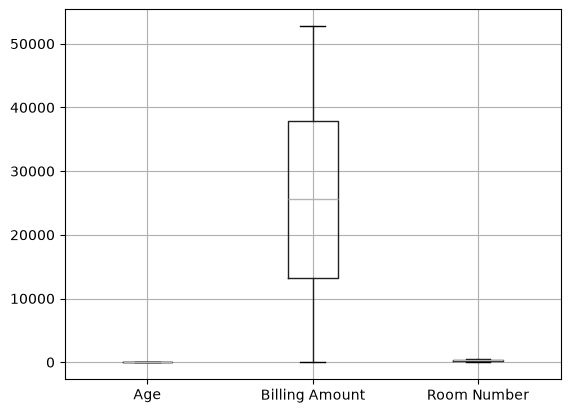

In [32]:
#  OUTLIERS
df[['Age', 'Billing Amount', 'Room Number']].boxplot()
print(df[['Age', 'Billing Amount', 'Room Number']].describe())

In [33]:
print("Cleaned shape:", df.shape)

Cleaned shape: (55392, 16)


In [34]:
medical_dummies = pd.get_dummies(
    df['Medical Condition'],
    prefix='Condition',
    dtype=int
)

medical_dummies.head()

,Condition_Arthritis,Condition_Asthma,Condition_Cancer,Condition_Diabetes,Condition_Hypertension,Condition_Obesity
0,0,0,1,0,0,0
1,0,0,0,0,0,1
2,0,0,0,0,0,1
3,0,0,0,1,0,0
4,0,0,1,0,0,0


In [36]:
analysis_df = pd.concat(
    [
        df[['Age', 'Billing Amount', 'Room Number']],
        medical_dummies
    ],
    axis=1
)

In [37]:
# Age
cur.execute(
    """SELECT
    [Medical Condition],
    COUNT(*) AS Patient_Count,
    AVG(Age) AS Average_Age,
    MIN(Age) AS Minimum_Age,
    MAX(Age) AS Maximum_Age
FROM patient_rawData
GROUP BY [Medical Condition]
ORDER BY Average_Age DESC;"""
)

results = cur.fetchall()

age_df = pd.DataFrame(
    results,
    columns=[
        'Medical Condition',
        'Patient Count',
        'Average Age',
        'Minimum Age',
        'Maximum Age'
    ]
)

age_df

,Medical Condition,Patient Count,Average Age,Minimum Age,Maximum Age
0,Asthma,8272,51.726064,18,85
1,Hypertension,8319,51.699964,18,85
2,Arthritis,8439,51.601138,18,85
3,Diabetes,8384,51.549380,18,85
4,Cancer,8294,51.525802,18,85
5,Obesity,8292,51.379764,18,85


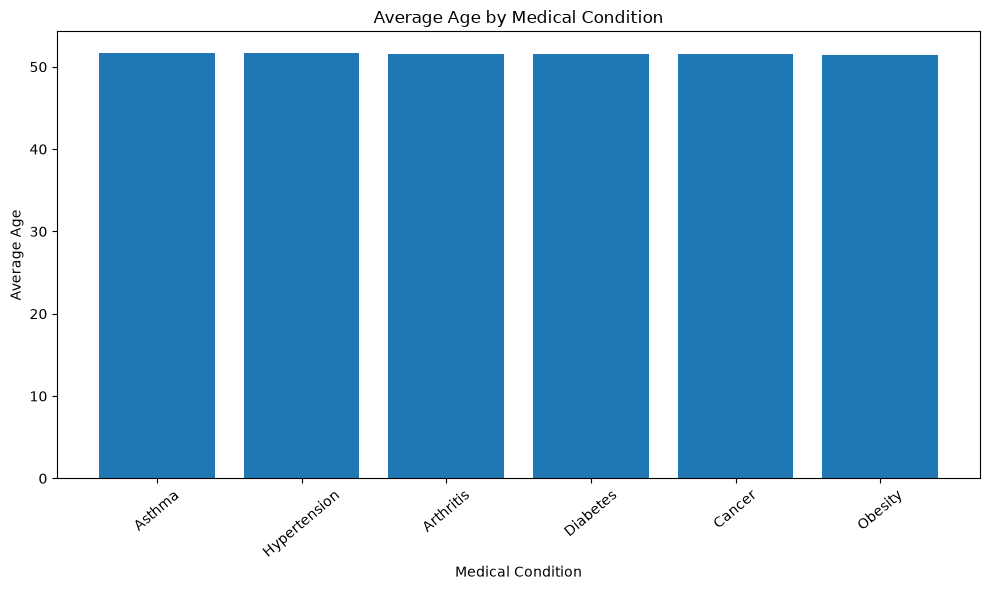

In [38]:
plt.figure(figsize=(10, 6))

plt.bar(
    age_df['Medical Condition'],
    age_df['Average Age']
)

plt.xlabel('Medical Condition')
plt.ylabel('Average Age')
plt.title('Average Age by Medical Condition')
plt.xticks(rotation=40)

plt.tight_layout()
plt.show()

In [39]:
# Billing
cur.execute("""
    SELECT
        [Medical Condition],
        COUNT(*) AS Patient_Count,
        AVG([Billing Amount]) AS Average_Billing,
        MIN([Billing Amount]) AS Minimum_Billing,
        MAX([Billing Amount]) AS Maximum_Billing
    FROM patient_rawData
    GROUP BY [Medical Condition]
    ORDER BY Average_Billing DESC;
""")

results = cur.fetchall()

billing_df = pd.DataFrame(
    results,
    columns=[
        'Medical Condition',
        'Patient Count',
        'Average Billing',
        'Minimum Billing',
        'Maximum Billing'
    ]
)

billing_df


,Medical Condition,Patient Count,Average Billing,Minimum Billing,Maximum Billing
0,Obesity,8292,25784.002661,-1310.272895,52024.726443
1,Asthma,8272,25681.211624,-1520.420555,52181.837792
2,Diabetes,8384,25654.531904,-1316.618581,52211.852966
3,Hypertension,8319,25494.217979,-1660.009373,52764.276736
4,Arthritis,8439,25486.204669,-1129.997176,52170.036854
5,Cancer,8294,25234.696065,-2008.492140,52373.032374


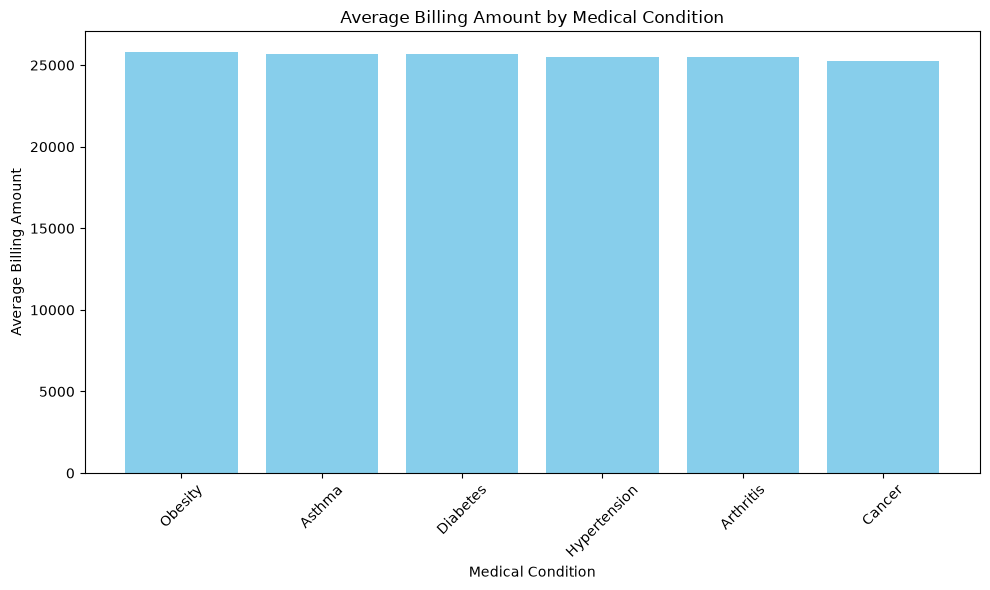

In [40]:
plt.figure(figsize=(10, 6))

plt.bar(
    billing_df['Medical Condition'],
    billing_df['Average Billing'],
    color='skyblue'
)

plt.xlabel('Medical Condition')
plt.ylabel('Average Billing Amount')
plt.title('Average Billing Amount by Medical Condition')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [41]:
#Gender
cur.execute("""
    SELECT
        [Medical Condition],
        Gender,
        COUNT(*) AS Patient_Count,
        ROUND(
            COUNT(*) * 100.0 /
            SUM(COUNT(*)) OVER (PARTITION BY [Medical Condition]),
            2
        ) AS Percentage
    FROM patient_rawData
    GROUP BY [Medical Condition], Gender
    ORDER BY [Medical Condition], Gender;
""")

results = cur.fetchall()

gender_condition_df = pd.DataFrame(
    results,
    columns=[
        'Medical Condition',
        'Gender',
        'Patient Count',
        'Percentage'
    ]
)

gender_condition_df

,Medical Condition,Gender,Patient Count,Percentage
0,Arthritis,Female,4251,50.37
1,Arthritis,Male,4188,49.63
2,Asthma,Female,4103,49.60
3,Asthma,Male,4169,50.40
4,Cancer,Female,4166,50.23
5,Cancer,Male,4128,49.77
6,Diabetes,Female,4201,50.11
7,Diabetes,Male,4183,49.89
8,Hypertension,Female,4157,49.97
9,Hypertension,Male,4162,50.03


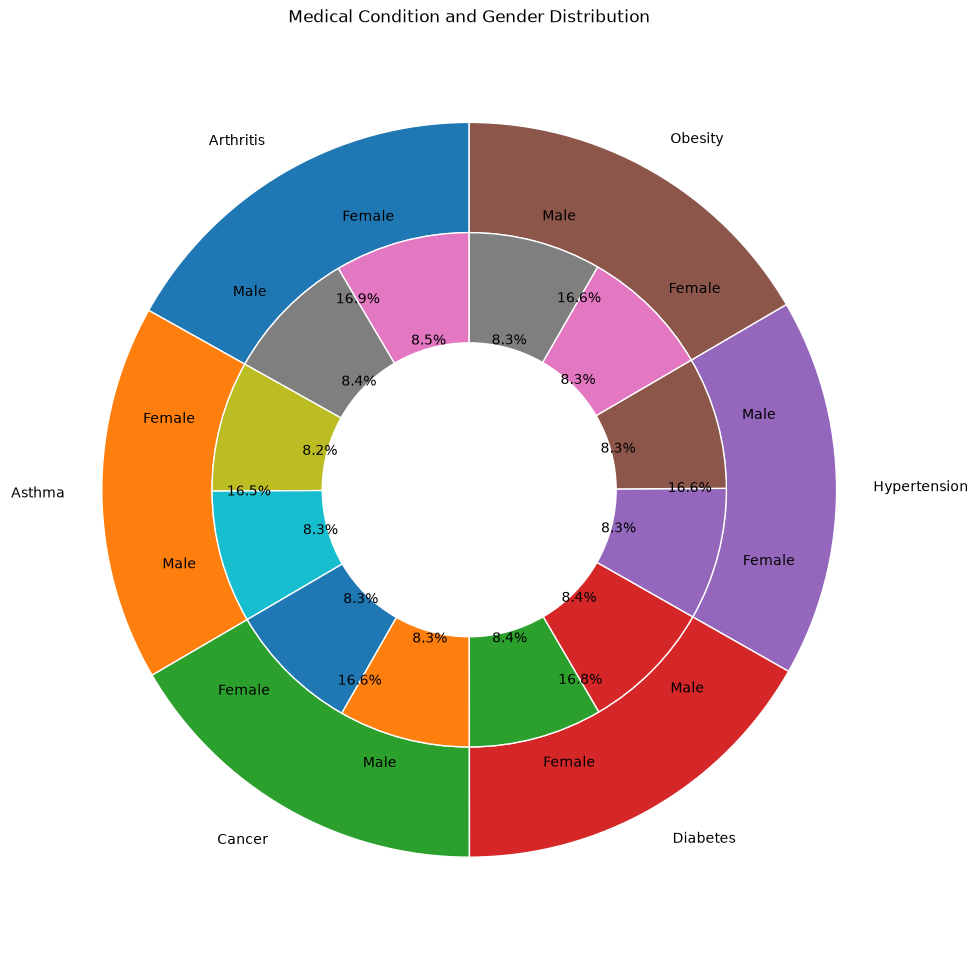

In [42]:
import matplotlib.pyplot as plt

# Total patients for each medical condition
condition_totals = (
    gender_condition_df
    .groupby('Medical Condition')['Patient Count']
    .sum()
)

# Gender counts within each condition
gender_counts = gender_condition_df.set_index(
    ['Medical Condition', 'Gender']
)['Patient Count']

conditions = condition_totals.index

# -----------------------------
# Outer ring: Medical Condition
# -----------------------------

outer_values = condition_totals.values

# -----------------------------
# Inner ring: Gender
# -----------------------------

inner_values = []
inner_labels = []

for condition in conditions:
    for gender in ['Female', 'Male']:
        try:
            value = gender_counts.loc[(condition, gender)]
        except KeyError:
            value = 0

        inner_values.append(value)
        inner_labels.append(gender)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

# Outer ring
ax.pie(
    outer_values,
    radius=1,
    labels=conditions,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.30, edgecolor='white')
)

# Inner ring
ax.pie(
    inner_values,
    radius=0.70,
    labels=inner_labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.30, edgecolor='white')
)

plt.title('Medical Condition and Gender Distribution')

plt.tight_layout()
plt.show()

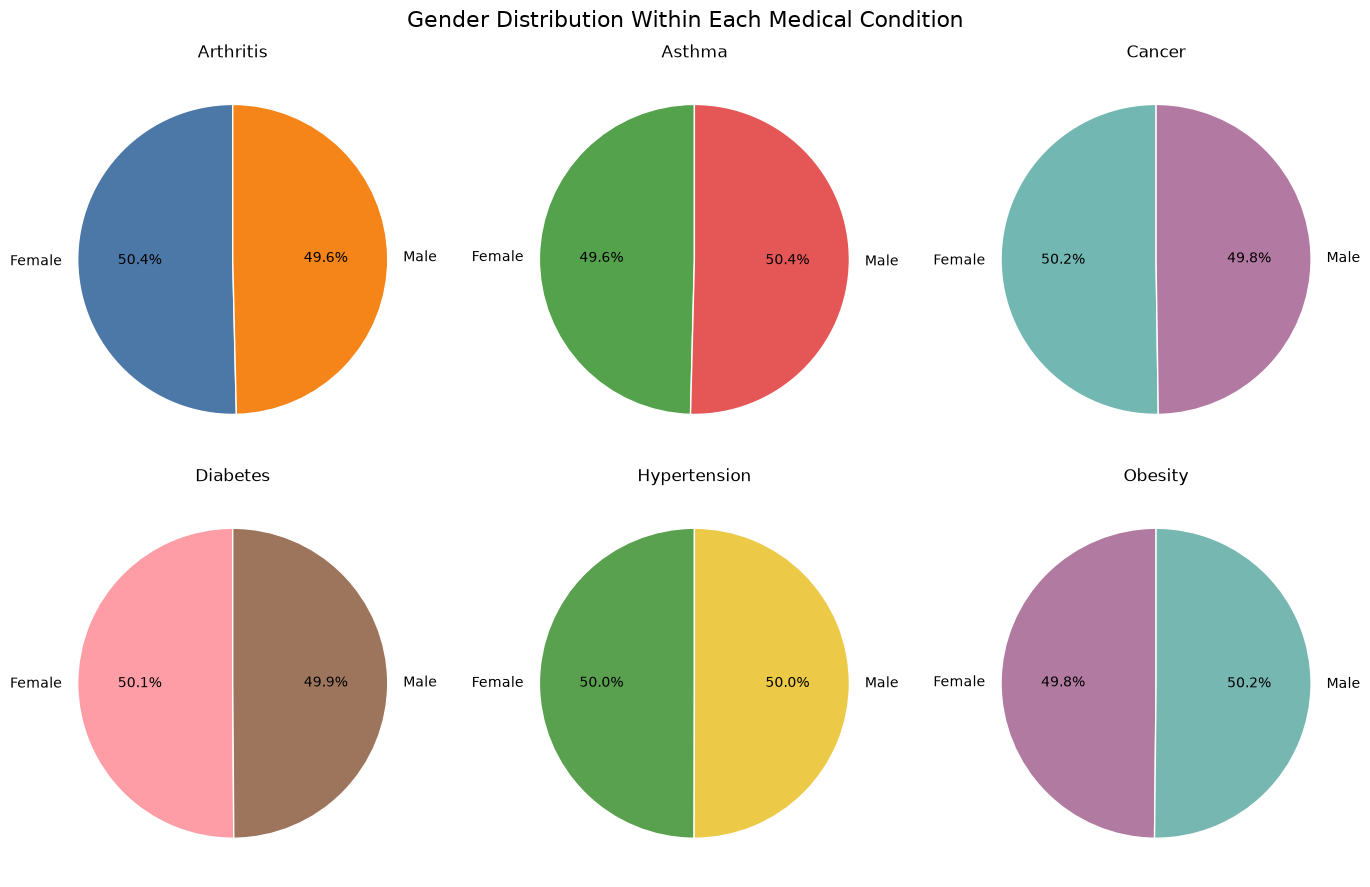

In [43]:
import matplotlib.pyplot as plt

conditions = gender_condition_df['Medical Condition'].unique()

# Different color pair for each medical condition
color_schemes = [
    ['#4C78A8', '#F58518'],
    ['#54A24B', '#E45756'],
    ['#72B7B2', '#B279A2'],
    ['#FF9DA6', '#9D755D'],
    ['#59A14F', '#EDC948'],
    ['#B07AA1', '#76B7B2']
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 9)
)

axes = axes.flatten()

for i, condition in enumerate(conditions):

    data = gender_condition_df[
        gender_condition_df['Medical Condition'] == condition
    ]

    # Calculate gender percentages within this condition
    total = data['Patient Count'].sum()

    percentages = (
        data['Patient Count'] / total * 100
    )

    axes[i].pie(
        data['Patient Count'],
        labels=data['Gender'],
        autopct='%1.1f%%',
        startangle=90,
        colors=color_schemes[i],
        wedgeprops=dict(edgecolor='white')
    )

    axes[i].set_title(condition)

plt.suptitle(
    'Gender Distribution Within Each Medical Condition',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [44]:
cur.execute("""
    SELECT
        [Medical Condition],
        [Blood Type],
        COUNT(*) AS Patient_Count,
        ROUND(
            COUNT(*) * 100.0 /
            SUM(COUNT(*)) OVER (PARTITION BY [Medical Condition]),
            2
        ) AS Percentage
    FROM patient_rawData
    GROUP BY [Medical Condition], [Blood Type]
    ORDER BY [Medical Condition], [Blood Type];
""")

results = cur.fetchall()
blood_type_df = pd.DataFrame(
    results,
    columns=[
        'Medical Condition',
        'Blood Type',
        'Patient Count',
        'Percentage'
    ]
)

blood_type_df


,Medical Condition,Blood Type,Patient Count,Percentage
0,Arthritis,A+,1027,12.17
1,Arthritis,A-,1050,12.44
2,Arthritis,AB+,1030,12.21
3,Arthritis,AB-,1069,12.67
4,Arthritis,B+,1077,12.76
5,Arthritis,B-,1064,12.61
6,Arthritis,O+,1082,12.82
7,Arthritis,O-,1040,12.32
8,Asthma,A+,1013,12.25
9,Asthma,A-,1056,12.77


In [45]:
cur.execute("""
    SELECT
        [Medical Condition],
        [Insurance Provider],
        COUNT(*) AS Patient_Count,
        ROUND(
            COUNT(*) * 100.0 /
            SUM(COUNT(*)) OVER (PARTITION BY [Medical Condition]),
            2
        ) AS Percentage
    FROM patient_rawData
    GROUP BY [Medical Condition], [Insurance Provider]
    ORDER BY [Medical Condition], Percentage DESC;
""")

results = cur.fetchall()

insurance_df = pd.DataFrame(
    results,
    columns=[
        'Medical Condition',
        'Insurance Provider',
        'Patient Count',
        'Percentage'
    ]
)

insurance_df

,Medical Condition,Insurance Provider,Patient Count,Percentage
0,Arthritis,Cigna,1706,20.22
1,Arthritis,UnitedHealthcare,1695,20.09
2,Arthritis,Blue Cross,1691,20.04
3,Arthritis,Medicare,1685,19.97
4,Arthritis,Aetna,1662,19.69
5,Asthma,Cigna,1695,20.49
6,Asthma,UnitedHealthcare,1681,20.32
7,Asthma,Blue Cross,1659,20.06
8,Asthma,Medicare,1648,19.92
9,Asthma,Aetna,1589,19.21


In [46]:
cur.execute("""
    SELECT
        [Medical Condition],
        [Admission Type],
        COUNT(*) AS Patient_Count,
        ROUND(
            COUNT(*) * 100.0 /
            SUM(COUNT(*)) OVER (PARTITION BY [Medical Condition]),
            2
        ) AS Percentage
    FROM patient_rawData
    GROUP BY [Medical Condition], [Admission Type]
    ORDER BY [Medical Condition], Percentage DESC;
""")

results = cur.fetchall()


admission_analysis_df = pd.DataFrame(
    results,
    columns=[
        'Medical Condition',
        'Admission Type',
        'Patient Count',
        'Percentage'
    ]
)

admission_analysis_df

,Medical Condition,Admission Type,Patient Count,Percentage
0,Arthritis,Urgent,2829,33.52
1,Arthritis,Elective,2823,33.45
2,Arthritis,Emergency,2787,33.03
3,Asthma,Elective,2809,33.96
4,Asthma,Urgent,2773,33.52
5,Asthma,Emergency,2690,32.52
6,Cancer,Elective,2819,33.99
7,Cancer,Urgent,2767,33.36
8,Cancer,Emergency,2708,32.65
9,Diabetes,Urgent,2903,34.63


In [47]:
cur.execute("""
    SELECT
        [Medical Condition],
        COUNT(*) AS Patient_Count,
        ROUND(
            COUNT(*) * 100.0 / (SELECT COUNT(*) FROM patient_rawData),
            2
        ) AS Percentage
    FROM patient_rawData
    GROUP BY [Medical Condition]
    ORDER BY Patient_Count DESC;
""")

results = cur.fetchall()

condition_df = pd.DataFrame(
    results,
    columns=['Medical Condition', 'Patient Count', 'Percentage']
)

condition_df

,Medical Condition,Patient Count,Percentage
0,Arthritis,8439,16.88
1,Diabetes,8384,16.77
2,Hypertension,8319,16.64
3,Cancer,8294,16.59
4,Obesity,8292,16.58
5,Asthma,8272,16.54


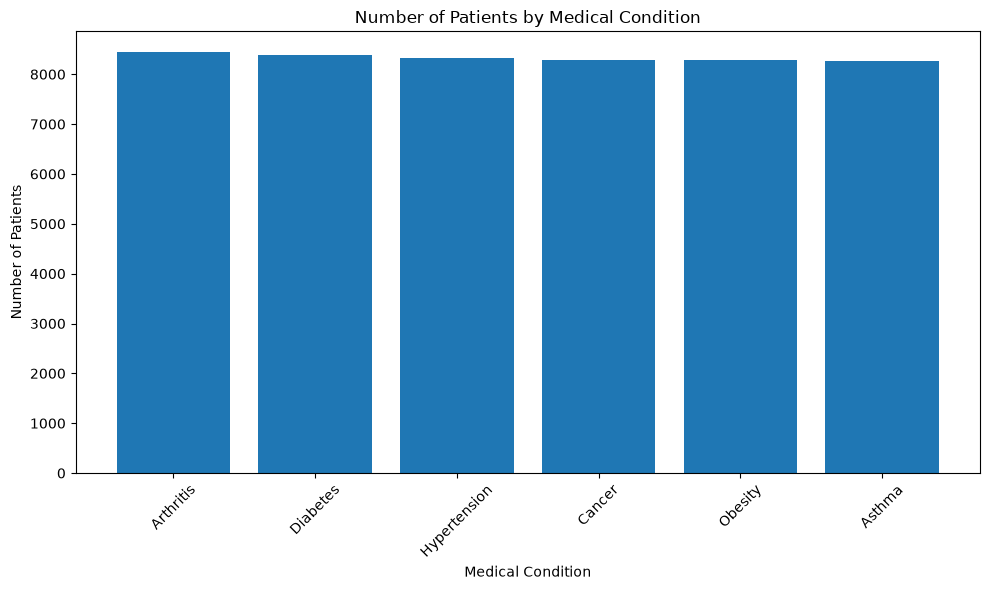

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    condition_df['Medical Condition'],
    condition_df['Patient Count']
)

plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')
plt.title('Number of Patients by Medical Condition')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [49]:
#   Test REsultd
cur.execute("""
    SELECT
        [Medical Condition],
        COUNT(*) AS Total_Patients,
        SUM(
            CASE
                WHEN [Test Results] = 'Abnormal' THEN 1
                ELSE 0
            END
        ) AS Abnormal_Count,
        ROUND(
            SUM(
                CASE
                    WHEN [Test Results] = 'Abnormal' THEN 1
                    ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS Abnormal_Percentage
    FROM patient_rawData
    GROUP BY [Medical Condition]
    ORDER BY Abnormal_Percentage DESC;
""")

results = cur.fetchall()

test_df = pd.DataFrame(
    results,
    columns=[
        'Medical Condition',
        'Total Patients',
        'Abnormal Count',
        'Abnormal Percentage'
    ]
)

test_df

,Medical Condition,Total Patients,Abnormal Count,Abnormal Percentage
0,Arthritis,8439,2908,34.46
1,Obesity,8292,2818,33.98
2,Diabetes,8384,2831,33.77
3,Cancer,8294,2797,33.72
4,Hypertension,8319,2721,32.71
5,Asthma,8272,2697,32.60


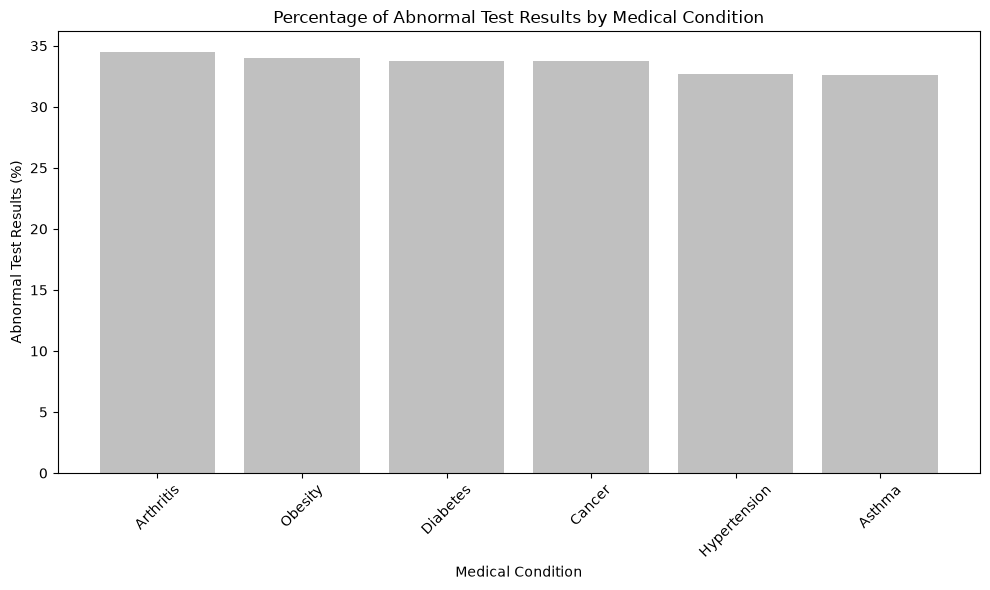

In [50]:
plt.figure(figsize=(10, 6))

plt.bar(
    test_df['Medical Condition'],
    test_df['Abnormal Percentage'],
    color='silver'
)

plt.xlabel('Medical Condition')
plt.ylabel('Abnormal Test Results (%)')
plt.title('Percentage of Abnormal Test Results by Medical Condition')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [51]:
cur.execute("""
    SELECT
        [Medical Condition],
        Medication,
        COUNT(*) AS Patient_Count
    FROM patient_rawData
    GROUP BY
        [Medical Condition],
        Medication
    ORDER BY
        [Medical Condition],
        Patient_Count DESC;
""")

results = cur.fetchall()

condition_medication_df = pd.DataFrame(
    results,
    columns=[
        'Medical Condition',
        'Medication',
        'Patient Count'
    ]
)

condition_medication_df

,Medical Condition,Medication,Patient Count
0,Arthritis,Aspirin,1733
1,Arthritis,Paracetamol,1698
2,Arthritis,Penicillin,1685
3,Arthritis,Lipitor,1663
4,Arthritis,Ibuprofen,1660
5,Asthma,Paracetamol,1705
6,Asthma,Penicillin,1679
7,Asthma,Lipitor,1649
8,Asthma,Ibuprofen,1620
9,Asthma,Aspirin,1619


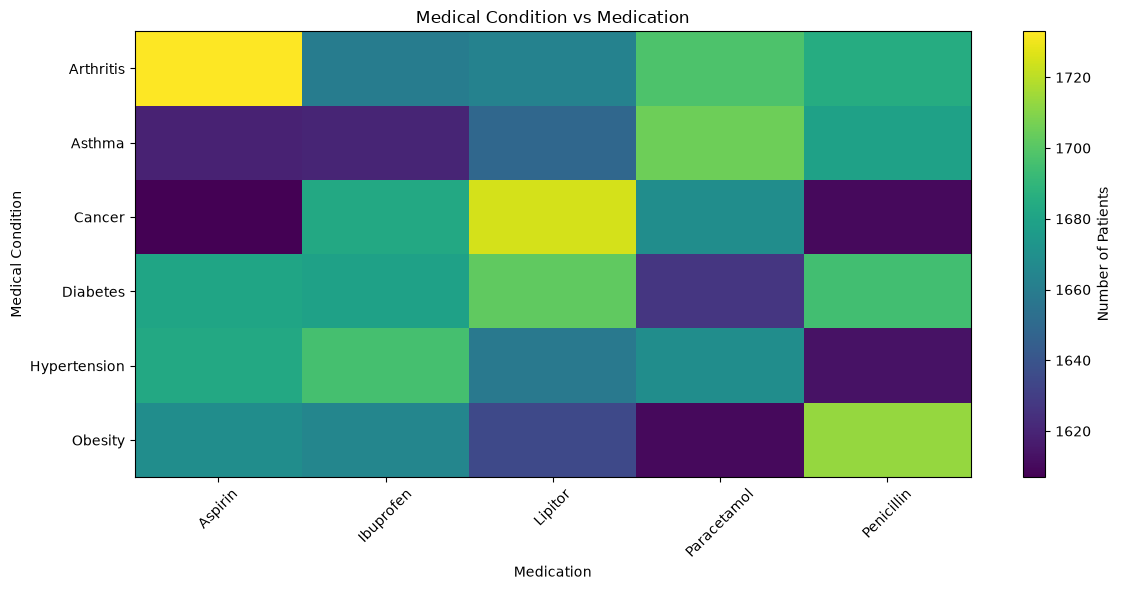

In [53]:
medication_pivot = condition_medication_df.pivot(
    index='Medical Condition',
    columns='Medication',
    values='Patient Count'
)

plt.figure(figsize=(12, 6))

plt.imshow(
    medication_pivot.fillna(0),
    aspect='auto'
)

plt.xticks(
    range(len(medication_pivot.columns)),
    medication_pivot.columns,
    rotation=45
)

plt.yticks(
    range(len(medication_pivot.index)),
    medication_pivot.index
)

plt.xlabel('Medication')
plt.ylabel('Medical Condition')
plt.title('Medical Condition vs Medication')

plt.colorbar(label='Number of Patients')

plt.tight_layout()
plt.show()

In [56]:
cur.execute("""
    SELECT
        CASE
            WHEN Age BETWEEN 0 AND 19 THEN '0-19'
            WHEN Age BETWEEN 20 AND 39 THEN '20-39'
            WHEN Age BETWEEN 40 AND 59 THEN '40-59'
            WHEN Age BETWEEN 60 AND 79 THEN '60-79'
            WHEN Age BETWEEN 80 AND 99 THEN '80-99'
            WHEN Age BETWEEN 100 AND 119 THEN '100-119'
        END AS Age_Group,

        [Medical Condition],

        COUNT(*) AS Patient_Count

    FROM patient_rawData

    GROUP BY
        CASE
            WHEN Age BETWEEN 0 AND 19 THEN '0-19'
            WHEN Age BETWEEN 20 AND 39 THEN '20-39'
            WHEN Age BETWEEN 40 AND 59 THEN '40-59'
            WHEN Age BETWEEN 60 AND 79 THEN '60-79'
            WHEN Age BETWEEN 80 AND 99 THEN '80-99'
            WHEN Age BETWEEN 100 AND 119 THEN '100-119'
        END,
        [Medical Condition]

    ORDER BY Age_Group, [Medical Condition];
""")

results = cur.fetchall()

age_group_df = pd.DataFrame(
    results,
    columns=[
        'Age Group',
        'Medical Condition',
        'Patient Count'
    ]
)

age_group_df

,Age Group,Medical Condition,Patient Count
0,0-19,Arthritis,261
1,0-19,Asthma,244
2,0-19,Cancer,242
3,0-19,Diabetes,238
4,0-19,Hypertension,248
5,0-19,Obesity,237
6,20-39,Arthritis,2466
7,20-39,Asthma,2408
8,20-39,Cancer,2458
9,20-39,Diabetes,2436


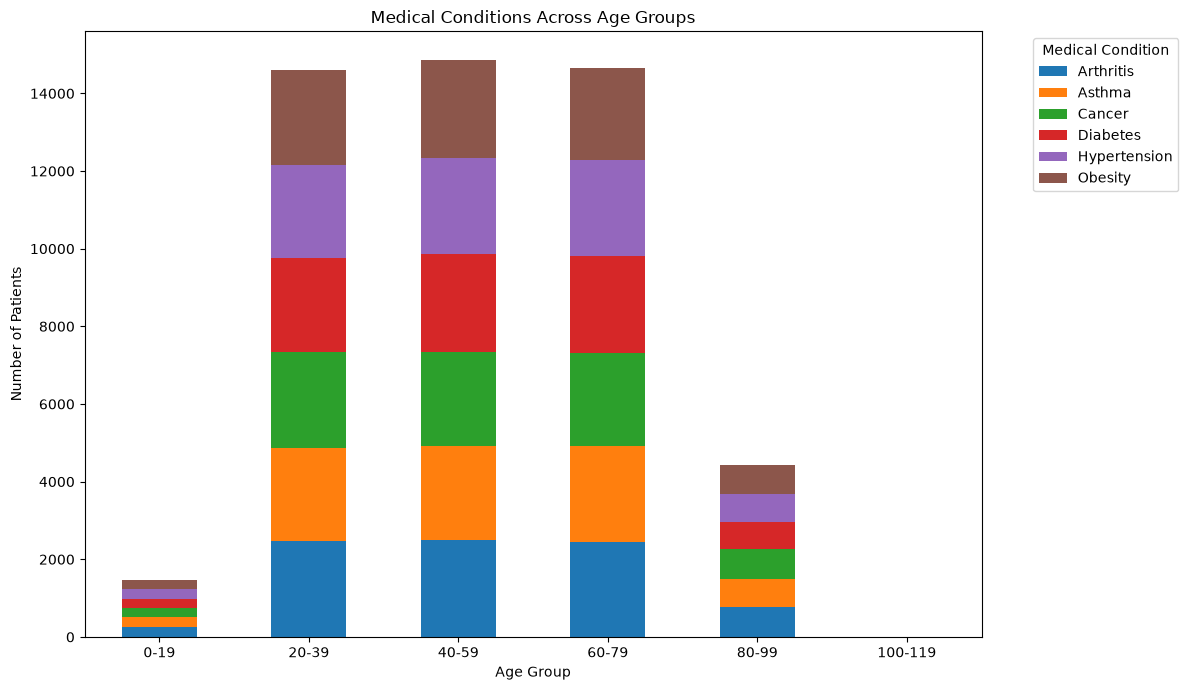

In [60]:
import matplotlib.pyplot as plt

age_pivot = age_group_df.pivot(
    index='Age Group',
    columns='Medical Condition',
    values='Patient Count'
).fillna(0)

# Keep age groups in the correct order
age_order = [
    '0-19',
    '20-39',
    '40-59',
    '60-79',
    '80-99',
    '100-119'
]

age_pivot = age_pivot.reindex(age_order)

ax = age_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7)
)

plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.title('Medical Conditions Across Age Groups')
plt.xticks(rotation=0)

plt.legend(
    title='Medical Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [67]:
# Remove exact duplicates from df (same logic already used for the SQL table above)
df = df.drop_duplicates(subset=target_columns, keep='first')
print("Shape after removing duplicates:", df.shape)


# Export cleaned dataset to Excel for the dashboard
df.to_excel('healthcare_dataset_cleaned.xlsx', index=False, sheet_name='Patient_Data')
print("Cleaned file saved:", df.shape)



Shape after removing duplicates: (50000, 15)
Cleaned file saved: (50000, 15)
